In [ ]:
import torch as t
import torch.nn as nn
import torch.optim as o
import torchvision as tv
import torchvision.transforms as tr
from torch.utils.data import DataLoader as dl, Subset as sb
import torch.nn.functional as f
import gc

d = t.device("cuda" if t.cuda.is_available() else "cpu")

def r_vgg(dsn, ep=10):
    sz = 64
    if dsn == 'm':
        tf = tr.Compose([tr.Grayscale(3), tr.Resize(sz), tr.ToTensor(), tr.Normalize((0.5,), (0.5,))])
        dt = tv.datasets.MNIST('./d', train=True, download=True, transform=tf)
        de = tv.datasets.MNIST('./d', train=False, download=True, transform=tf)
    else:
        tf = tr.Compose([tr.Resize(sz), tr.ToTensor(), tr.Normalize((0.5,), (0.5,))])
        dt = tv.datasets.CIFAR10('./d', train=True, download=True, transform=tf)
        de = tv.datasets.CIFAR10('./d', train=False, download=True, transform=tf)

    dt = sb(dt, range(500))
    de = sb(de, range(100))

    lt = dl(dt, batch_size=32, shuffle=True)
    le = dl(de, batch_size=32, shuffle=False)

    m = tv.models.vgg11(weights=None, num_classes=10).to(d)
    op = o.Adam(m.parameters(), lr=0.001)
    lf = nn.BCEWithLogitsLoss()

    for i in range(ep):
        m.train()
        tc = 0
        tt = 0
        for x, y in lt:
            x, y = x.to(d), y.to(d)
            op.zero_grad()
            pd = m(x)
            ls = lf(pd, f.one_hot(y, 10).float())
            ls.backward()
            op.step()
            _, pr = t.max(pd.data, 1)
            tt += y.size(0)
            tc += (pr == y).sum().item()
        print(f"VGG {dsn} | E {i+1}/{ep} | Tr={100*tc/tt:.1f}%")

    m.eval()
    ec = 0
    et = 0
    with t.no_grad():
        for x, y in le:
            x, y = x.to(d), y.to(d)
            pd = m(x)
            _, pr = t.max(pd.data, 1)
            et += y.size(0)
            ec += (pr == y).sum().item()

    ta = 100 * tc / tt
    ea = 100 * ec / et
    print(f"FINAL -> VGG | BCE | {dsn} | Tr={ta:.2f}% | Te={ea:.2f}%\n")

    del m, op, lt, le, dt, de
    gc.collect()
    t.cuda.empty_cache()

r_vgg('m', 10)
r_vgg('c', 10)

VGG m | E 1/10 | Tr=9.2%
VGG m | E 2/10 | Tr=10.0%
VGG m | E 3/10 | Tr=11.6%
VGG m | E 4/10 | Tr=9.2%
VGG m | E 5/10 | Tr=7.2%
VGG m | E 6/10 | Tr=10.2%
VGG m | E 7/10 | Tr=12.0%
VGG m | E 8/10 | Tr=10.2%
VGG m | E 9/10 | Tr=12.8%
VGG m | E 10/10 | Tr=12.6%
FINAL -> VGG | BCE | m | Tr=12.60% | Te=14.00%

VGG c | E 1/10 | Tr=11.2%
VGG c | E 2/10 | Tr=11.4%
VGG c | E 3/10 | Tr=10.2%
VGG c | E 4/10 | Tr=11.6%
VGG c | E 5/10 | Tr=8.4%
VGG c | E 6/10 | Tr=11.2%
VGG c | E 7/10 | Tr=8.6%
VGG c | E 8/10 | Tr=12.4%
VGG c | E 9/10 | Tr=9.6%
VGG c | E 10/10 | Tr=12.2%
FINAL -> VGG | BCE | c | Tr=12.20% | Te=6.00%



In [ ]:
import torch as t
import torch.nn as nn
import torch.optim as o
import torchvision as tv
import torchvision.transforms as tr
from torch.utils.data import DataLoader as dl, Subset as sb
import gc

d = t.device("cuda" if t.cuda.is_available() else "cpu")

class FL(nn.Module):
    def __init__(s, a=1, g=2):
        super(FL, s).__init__()
        s.a = a
        s.g = g
        s.c = nn.CrossEntropyLoss(reduction='none')
    def forward(s, i, tg):
        l = s.c(i, tg)
        p = t.exp(-l)
        fl = s.a * (1 - p)**s.g * l
        return fl.mean()

def r_alx(dsn, ep=20):
    sz = 64
    if dsn == 'm':
        tf = tr.Compose([tr.Grayscale(3), tr.Resize(sz), tr.ToTensor(), tr.Normalize((0.5,), (0.5,))])
        dt = tv.datasets.MNIST('./d', train=True, download=True, transform=tf)
        de = tv.datasets.MNIST('./d', train=False, download=True, transform=tf)
    else:
        tf = tr.Compose([tr.Resize(sz), tr.ToTensor(), tr.Normalize((0.5,), (0.5,))])
        dt = tv.datasets.CIFAR10('./d', train=True, download=True, transform=tf)
        de = tv.datasets.CIFAR10('./d', train=False, download=True, transform=tf)

    dt = sb(dt, range(500))
    de = sb(de, range(100))

    lt = dl(dt, batch_size=32, shuffle=True)
    le = dl(de, batch_size=32, shuffle=False)

    m = tv.models.alexnet(weights=None, num_classes=10).to(d)
    op = o.SGD(m.parameters(), lr=0.01, momentum=0.9)
    lf = FL()

    for i in range(ep):
        m.train()
        tc = 0
        tt = 0
        for x, y in lt:
            x, y = x.to(d), y.to(d)
            op.zero_grad()
            pd = m(x)
            ls = lf(pd, y)
            ls.backward()
            op.step()
            _, pr = t.max(pd.data, 1)
            tt += y.size(0)
            tc += (pr == y).sum().item()
        print(f"AlexNet {dsn} | E {i+1}/{ep} | Tr={100*tc/tt:.1f}%")

    m.eval()
    ec = 0
    et = 0
    with t.no_grad():
        for x, y in le:
            x, y = x.to(d), y.to(d)
            pd = m(x)
            _, pr = t.max(pd.data, 1)
            et += y.size(0)
            ec += (pr == y).sum().item()

    ta = 100 * tc / tt
    ea = 100 * ec / et
    print(f"FINAL -> AlexNet | FL | {dsn} | Tr={ta:.2f}% | Te={ea:.2f}%\n")

    del m, op, lt, le, dt, de
    gc.collect()
    t.cuda.empty_cache()

r_alx('m', 20)
r_alx('c', 20)

AlexNet m | E 1/20 | Tr=11.8%
AlexNet m | E 2/20 | Tr=13.2%
AlexNet m | E 3/20 | Tr=13.2%
AlexNet m | E 4/20 | Tr=13.2%
AlexNet m | E 5/20 | Tr=13.2%
AlexNet m | E 6/20 | Tr=13.2%
AlexNet m | E 7/20 | Tr=13.2%
AlexNet m | E 8/20 | Tr=13.2%
AlexNet m | E 9/20 | Tr=13.2%
AlexNet m | E 10/20 | Tr=14.0%
AlexNet m | E 11/20 | Tr=18.6%
AlexNet m | E 12/20 | Tr=27.2%
AlexNet m | E 13/20 | Tr=13.0%
AlexNet m | E 14/20 | Tr=12.4%
AlexNet m | E 15/20 | Tr=19.2%
AlexNet m | E 16/20 | Tr=25.4%
AlexNet m | E 17/20 | Tr=31.0%
AlexNet m | E 18/20 | Tr=38.2%
AlexNet m | E 19/20 | Tr=46.0%
AlexNet m | E 20/20 | Tr=56.4%
FINAL -> AlexNet | FL | m | Tr=56.40% | Te=66.00%

AlexNet c | E 1/20 | Tr=10.0%
AlexNet c | E 2/20 | Tr=13.0%
AlexNet c | E 3/20 | Tr=13.0%
AlexNet c | E 4/20 | Tr=13.0%
AlexNet c | E 5/20 | Tr=13.0%
AlexNet c | E 6/20 | Tr=13.0%
AlexNet c | E 7/20 | Tr=13.0%
AlexNet c | E 8/20 | Tr=13.0%
AlexNet c | E 9/20 | Tr=13.0%
AlexNet c | E 10/20 | Tr=13.0%
AlexNet c | E 11/20 | Tr=13.0%
AlexNe

In [ ]:
import torch as t
import torch.nn as nn
import torch.optim as o
import torchvision as tv
import torchvision.transforms as tr
from torch.utils.data import DataLoader as dl, Subset as sb
import torch.nn.functional as f
import gc

d = t.device("cuda" if t.cuda.is_available() else "cpu")

class AF(nn.Module):
    def __init__(s, ic, oc, sv=64.0, m=0.50):
        super(AF, s).__init__()
        s.sv = sv
        s.m = m
        s.w = nn.Parameter(t.FloatTensor(oc, ic))
        nn.init.xavier_uniform_(s.w)
        s.c = nn.CrossEntropyLoss()
    def forward(s, i, lb):
        cw = f.normalize(s.w, p=2, dim=1)
        ci = f.normalize(i, p=2, dim=1)
        cs = f.linear(ci, cw)
        th = t.acos(t.clamp(cs, -1.0 + 1e-7, 1.0 - 1e-7))
        nt = th + s.m
        no = t.cos(nt)
        oh = t.zeros_like(cs)
        oh.scatter_(1, lb.view(-1, 1).long(), 1)
        r = oh * no + (1 - oh) * cs
        r = r * s.sv
        return s.c(r, lb)

def r_res(dsn, ep=15):
    sz = 64
    if dsn == 'm':
        tf = tr.Compose([tr.Grayscale(3), tr.Resize(sz), tr.ToTensor(), tr.Normalize((0.5,), (0.5,))])
        dt = tv.datasets.MNIST('./d', train=True, download=True, transform=tf)
        de = tv.datasets.MNIST('./d', train=False, download=True, transform=tf)
    else:
        tf = tr.Compose([tr.Resize(sz), tr.ToTensor(), tr.Normalize((0.5,), (0.5,))])
        dt = tv.datasets.CIFAR10('./d', train=True, download=True, transform=tf)
        de = tv.datasets.CIFAR10('./d', train=False, download=True, transform=tf)

    dt = sb(dt, range(500))
    de = sb(de, range(100))

    lt = dl(dt, batch_size=32, shuffle=True)
    le = dl(de, batch_size=32, shuffle=False)

    m = tv.models.resnet18(weights=None, num_classes=10).to(d)
    op = o.Adam(m.parameters(), lr=0.001)
    lf = AF(10, 10).to(d)

    for i in range(ep):
        m.train()
        tc = 0
        tt = 0
        for x, y in lt:
            x, y = x.to(d), y.to(d)
            op.zero_grad()
            pd = m(x)
            ls = lf(pd, y)
            ls.backward()
            op.step()
            _, pr = t.max(pd.data, 1)
            tt += y.size(0)
            tc += (pr == y).sum().item()
        print(f"ResNet {dsn} | E {i+1}/{ep} | Tr={100*tc/tt:.1f}%")

    m.eval()
    ec = 0
    et = 0
    with t.no_grad():
        for x, y in le:
            x, y = x.to(d), y.to(d)
            pd = m(x)
            _, pr = t.max(pd.data, 1)
            et += y.size(0)
            ec += (pr == y).sum().item()

    ta = 100 * tc / tt
    ea = 100 * ec / et
    print(f"FINAL -> ResNet | AF | {dsn} | Tr={ta:.2f}% | Te={ea:.2f}%\n")

    del m, op, lt, le, dt, de
    gc.collect()
    t.cuda.empty_cache()

r_res('m', 15)
r_res('c', 15)

ResNet m | E 1/15 | Tr=10.4%
ResNet m | E 2/15 | Tr=6.2%
ResNet m | E 3/15 | Tr=8.6%
ResNet m | E 4/15 | Tr=8.2%
ResNet m | E 5/15 | Tr=10.4%
ResNet m | E 6/15 | Tr=9.2%
ResNet m | E 7/15 | Tr=8.6%
ResNet m | E 8/15 | Tr=12.0%
ResNet m | E 9/15 | Tr=9.4%
ResNet m | E 10/15 | Tr=12.2%
ResNet m | E 11/15 | Tr=10.2%
ResNet m | E 12/15 | Tr=9.4%
ResNet m | E 13/15 | Tr=10.4%
ResNet m | E 14/15 | Tr=9.8%
ResNet m | E 15/15 | Tr=9.8%
FINAL -> ResNet | AF | m | Tr=9.80% | Te=13.00%

ResNet c | E 1/15 | Tr=7.6%
ResNet c | E 2/15 | Tr=7.4%
ResNet c | E 3/15 | Tr=8.6%
ResNet c | E 4/15 | Tr=7.8%
ResNet c | E 5/15 | Tr=7.6%
ResNet c | E 6/15 | Tr=8.8%
ResNet c | E 7/15 | Tr=7.2%
ResNet c | E 8/15 | Tr=9.8%
ResNet c | E 9/15 | Tr=13.2%
ResNet c | E 10/15 | Tr=12.2%
ResNet c | E 11/15 | Tr=12.4%
ResNet c | E 12/15 | Tr=13.0%
ResNet c | E 13/15 | Tr=13.0%
ResNet c | E 14/15 | Tr=15.2%
ResNet c | E 15/15 | Tr=16.6%
FINAL -> ResNet | AF | c | Tr=16.60% | Te=6.00%



Training BCE Model...
E 1/5 done
E 2/5 done
E 3/5 done
E 4/5 done
E 5/5 done

Training ArcFace Model...
E 1/5 done
E 2/5 done
E 3/5 done
E 4/5 done
E 5/5 done

Generating t-SNE Plot...


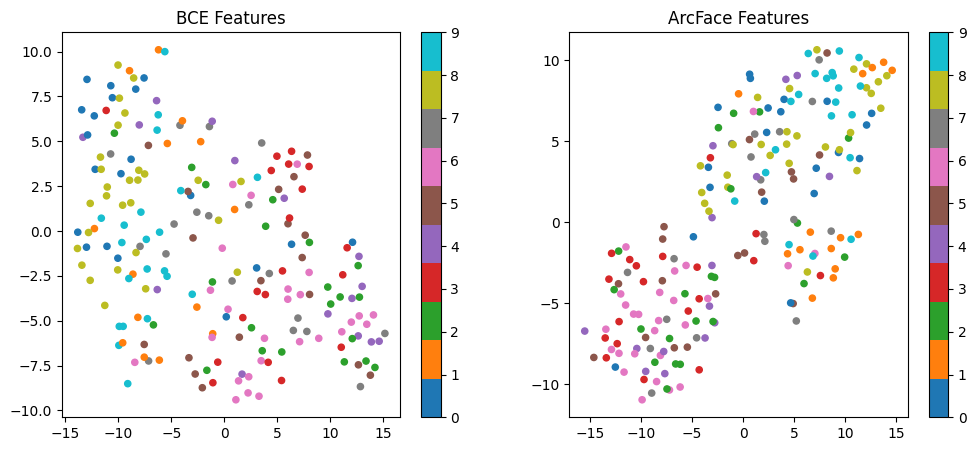

In [ ]:
import torch as t
import torch.nn as nn
import torch.optim as o
import torchvision as tv
import torchvision.transforms as tr
from torch.utils.data import DataLoader as dl, Subset as sb
import torch.nn.functional as f
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

d = t.device("cuda" if t.cuda.is_available() else "cpu")

class AF(nn.Module):
    def __init__(s, ic, oc, sv=64.0, m=0.50):
        super(AF, s).__init__()
        s.sv = sv
        s.m = m
        s.w = nn.Parameter(t.FloatTensor(oc, ic))
        nn.init.xavier_uniform_(s.w)
        s.c = nn.CrossEntropyLoss()
    def forward(s, i, lb):
        cw = f.normalize(s.w, p=2, dim=1)
        ci = f.normalize(i, p=2, dim=1)
        cs = f.linear(ci, cw)
        th = t.acos(t.clamp(cs, -1.0 + 1e-7, 1.0 - 1e-7))
        nt = th + s.m
        no = t.cos(nt)
        oh = t.zeros_like(cs)
        oh.scatter_(1, lb.view(-1, 1).long(), 1)
        r = oh * no + (1 - oh) * cs
        return s.c(r * s.sv, lb)

tf = tr.Compose([tr.Resize(64), tr.ToTensor(), tr.Normalize((0.5,), (0.5,))])
d_tr = tv.datasets.CIFAR10('./d', train=True, download=True, transform=tf)
d_te = tv.datasets.CIFAR10('./d', train=False, download=True, transform=tf)
d_tr = sb(d_tr, range(500))
d_te = sb(d_te, range(200))

l_tr = dl(d_tr, batch_size=32, shuffle=True)
l_te = dl(d_te, batch_size=32, shuffle=False)

class FE(nn.Module):
    def __init__(s, m):
        super(FE, s).__init__()
        s.f = nn.Sequential(*list(m.children())[:-1])
    def forward(s, x):
        return t.flatten(s.f(x), 1)

def tr_m(lf_t, i_af=False, ep=5):
    m = tv.models.resnet18(weights=None, num_classes=10).to(d)
    op = o.Adam(m.parameters(), lr=0.001)
    for i in range(ep):
        m.train()
        for x, y in l_tr:
            x, y = x.to(d), y.to(d)
            op.zero_grad()
            pd = m(x)
            if i_af:
                ls = lf_t(pd, y)
            else:
                ls = lf_t(pd, f.one_hot(y, 10).float())
            ls.backward()
            op.step()
        print(f"E {i+1}/{ep} done")
    return m

def ex_f(m, l):
    m.eval()
    fs = []
    ls = []
    fe = FE(m).to(d)
    with t.no_grad():
        for x, y in l:
            fs.append(fe(x.to(d)).cpu())
            ls.append(y.cpu())
    return t.cat(fs), t.cat(ls)

print("Training BCE Model...")
mb = tr_m(nn.BCEWithLogitsLoss(), False, 5)
fb, lb = ex_f(mb, l_te)

print("\nTraining ArcFace Model...")
ma = tr_m(AF(10, 10).to(d), True, 5)
fa, la = ex_f(ma, l_te)

def pl_t(f1, l1, f2, l2):
    t1 = TSNE(n_components=2, random_state=42).fit_transform(f1.numpy())
    t2 = TSNE(n_components=2, random_state=42).fit_transform(f2.numpy())

    fg, ax = plt.subplots(1, 2, figsize=(12, 5))
    s1 = ax[0].scatter(t1[:, 0], t1[:, 1], c=l1.numpy(), cmap='tab10', s=20)
    ax[0].set_title('BCE Features')
    fg.colorbar(s1, ax=ax[0])

    s2 = ax[1].scatter(t2[:, 0], t2[:, 1], c=l2.numpy(), cmap='tab10', s=20)
    ax[1].set_title('ArcFace Features')
    fg.colorbar(s2, ax=ax[1])
    plt.show()

print("\nGenerating t-SNE Plot...")
pl_t(fb, lb, fa, la)